In [1]:
from graph_transformer_long_range_niches.tl import pad_batch
from graph_transformer_long_range_niches._paths import CFG_FILES, RESULTS, COSMX_PANCREAS, COSMX_PANCREAS_S1
from graph_transformer_long_range_niches.model.gnn_transformer import LitGNNTransformer
from graph_transformer_long_range_niches.pl import CustomColormap, plot_attention_sender_receiver, plot_attention_sender_receiver, SelfAttentionRelevance, calculate_attention, normalized_attention, normalized_class_attention
from graph_transformer_long_range_niches.pp import prepare_geome_dataset, split_adata
from graph_transformer_long_range_niches.config import load_config

import warnings
warnings.filterwarnings("ignore")

from torch_geometric.loader import DataLoader

from pathlib import Path
import wandb
import torch
import os

## plotting
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pickle

import scanpy as sc
import squidpy as sq

from sklearn.preprocessing import MinMaxScaler

# Evaluation: Pancreas CosmX data

In this notebook we explore the performance of InterScale on cell-level tasks:

1. Cell type x Cell type interaction strength
2. Spatial observation of cell-to-cell interactions

In [2]:
def load_model(PATH, model_type = "gnn-transformer"):
    model_transformer_ckpt = torch.load(Path(RESULTS, FOLDER, f"{PATH}_{model_type}.ckpt"))
    cfg = model_transformer_ckpt['hyper_parameters']['cfg']
    cfg.dataset.loss = 'GaussianLLN'
    model_transformer = LitGNNTransformer(model_transformer_ckpt['hyper_parameters']['cfg'])
    model_transformer.load_state_dict(model_transformer_ckpt['state_dict'])
    return model_transformer, cfg

## Load model and data

In [3]:
FOLDER = "cosmx_pancreas"
CONDITION_DATA = "pancreas_condition_sliding_window_1_44"
CELLTYPE_DATA = "pancreas_cell_type_coarse_sliding_window_1_44"
GEX_DATA = "pancreas_None_sliding_window_3_2_44"

In [4]:
model_transformer_condition, cfg_condition = load_model(CONDITION_DATA, model_type = "gnn-transformer")
model_transformer_ct, cfg_ct = load_model(CELLTYPE_DATA, model_type = "gnn-transformer")

RuntimeError: Error(s) in loading state_dict for LitGNNTransformer:
	Missing key(s) in state_dict: "mask_token". 

In [5]:
adata = sc.read_h5ad(Path(COSMX_PANCREAS_S1))
adata

AnnData object with n_obs × n_vars = 104816 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'niche_label', 'x', 'y', 'globalX', 'globalY', 'sliding_window_1', 'sliding_window_2', 'sliding_window_3', 'sliding_window_4', 'sliding_window'
    uns: 'cell_type_coarse_colors', 'sliding_window_1_colors', 'sliding_window_2_colors', 'spatial', 'spatial_neighbors'
    obsm: 'spatial', 'spatial_fov'
    layers: 'counts'

In [7]:
obs_csv = pd.read_csv(Path(RESULTS, FOLDER, f"{CONDITION_DATA}_obs.csv"))
obs_csv = obs_csv.rename(columns={'Unnamed: 0': 'obs_names'})
obs_csv

,obs_names,fov,Area,AspectRatio,CenterX_global_px,CenterY_global_px,Width,Height,Mean.MembraneStain,Max.MembraneStain,...,x,y,globalX,globalY,sliding_window_1,sliding_window_2,sliding_window_3,sliding_window_4,sliding_window,split
0,1_1,1,3038,2.05,-25945.777778,122127.000000,88,43,1830,13181,...,-25945.777778,122127.000000,832,3627,1_1_3,1_2_2,1_3_3,1_4_2,1_3,train
1,2_1,1,2507,1.34,-25566.777778,122125.000000,63,47,902,5621,...,-25566.777778,122125.000000,1211,3625,1_1_3,1_2_3,1_3_3,1_4_3,1_3,train
2,3_1,1,7970,1.53,-25278.777778,122102.000000,142,93,1476,7846,...,-25278.777778,122102.000000,1499,3602,1_1_3,1_2_3,1_3_3,1_4_3,1_3,train
3,4_1,1,5041,1.80,-24148.777778,122116.000000,115,64,931,7451,...,-24148.777778,122116.000000,2629,3616,1_1_4,1_2_3,1_3_4,1_4_3,1_4,train
4,5_1,1,3835,1.17,-24070.777778,122108.000000,95,81,1016,7478,...,-24070.777778,122108.000000,2707,3608,1_1_4,1_2_3,1_3_4,1_4_3,1_4,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104811,4724_24,24,1666,1.02,26190.222222,139474.888889,48,47,431,1514,...,26190.222222,139474.888889,1818,36,24_1_0,24_2_0,24_3_-3,24_4_-3,24_0,val
104812,4725_24,24,2624,1.35,29172.222222,139465.888889,69,51,688,7950,...,29172.222222,139465.888889,4800,27,24_1_2,24_2_1,24_3_-1,24_4_-2,24_2,val
104813,4726_24,24,2473,1.04,27394.222222,139466.888889,56,54,408,2139,...,27394.222222,139466.888889,3022,28,24_1_1,24_2_1,24_3_-2,24_4_-2,24_1,val
104814,4727_24,24,1821,1.33,24815.222222,139460.888889,56,42,223,1113,...,24815.222222,139460.888889,443,22,24_1_0,24_2_-1,24_3_-3,24_4_-4,24_0,val


In [8]:
adata.obs['split'] = np.array(obs_csv['split'].values)

In [7]:
with open(Path(Path(RESULTS, FOLDER, f"{CONDITION_DATA}.pkl")), 'rb') as f:
    pyg_data = pickle.load(f)
train_pyg = pyg_data[0]
val_pyg = pyg_data[1]
print('train: ', len(train_pyg), 'val: ', len(val_pyg))

train:  108 val:  30


In [7]:
# Creating a DataFrame from 'split', 'fov', and 'condition'
df = adata.obs[['split', 'fov', 'condition']]
value_counts = pd.DataFrame(df.values, columns=df.columns).value_counts()
print(value_counts)

split  fov  condition
train  23   ND           5583
       15   ND           5401
       20   ND           5299
       12   ND           5208
       16   ND           5045
       13   ND           4935
       17   ND           4929
       18   ND           4819
       22   ND           4810
val    7    T1D          4807
       24   ND           4715
train  8    T1D          4657
       9    T1D          4547
       1    T1D          4499
val    2    T1D          4450
train  10   T1D          4423
       19   ND           4342
       4    T1D          4274
val    6    T1D          4206
train  21   ND           4053
val    3    T1D          4000
train  11   T1D          3493
       14   ND           2321
Name: count, dtype: int64


## Attention cell-level analysis on FOV 12

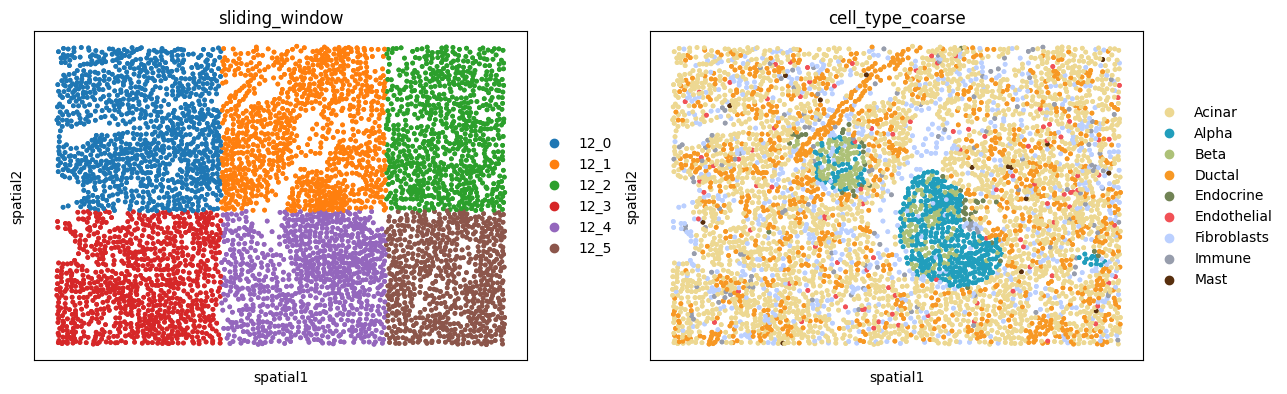

In [47]:
sq.pl.spatial_scatter(
                sub_adata,
                color = ['sliding_window', 'cell_type_coarse'],
                spatial_key = 'spatial',
                shape=None,
    )

In [11]:
cfg = model_transformer_ckpt['hyper_parameters']['cfg']

In [12]:
sub_adata, attention_matrix_dict = calculate_attention(adata, cfg, model_transformer, obs_col = 'fov', class_name = '12', library_key='sliding_window')

call new
{'condition': ['ND']}
call new
{'condition': []}
DataBatch(x=[1035, 979], edge_index=[2, 1266], y=[1035, 1], obs_names=[1035], batch=[1035], ptr=[2]) 12_0
Category mask:  torch.Size([1001, 1, 128])
1001
Layer 1 attention gradient shape: torch.Size([4, 1001, 1001])
Layer 1 attention output weights shape: torch.Size([4, 1001, 1001])
Average attention map shape: torch.Size([1001, 1001])
I:  tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])
Layer 2 attention gradient shape: torch.Size([4, 1001, 1001])
Layer 2 attention output weights shape: torch.Size([4, 1001, 1001])
Average attention map shape: torch.Size([1001, 1001])
I:  tensor([[1.0000e+00, 1.8263e-05, 2.4871e-05,  ..., 0.0000e+00, 2.5526e-05,
         9.8315e-06],
        [1.0906e-08, 1.0000e+00, 2.3743e-08,  ..., 6.8456e-09

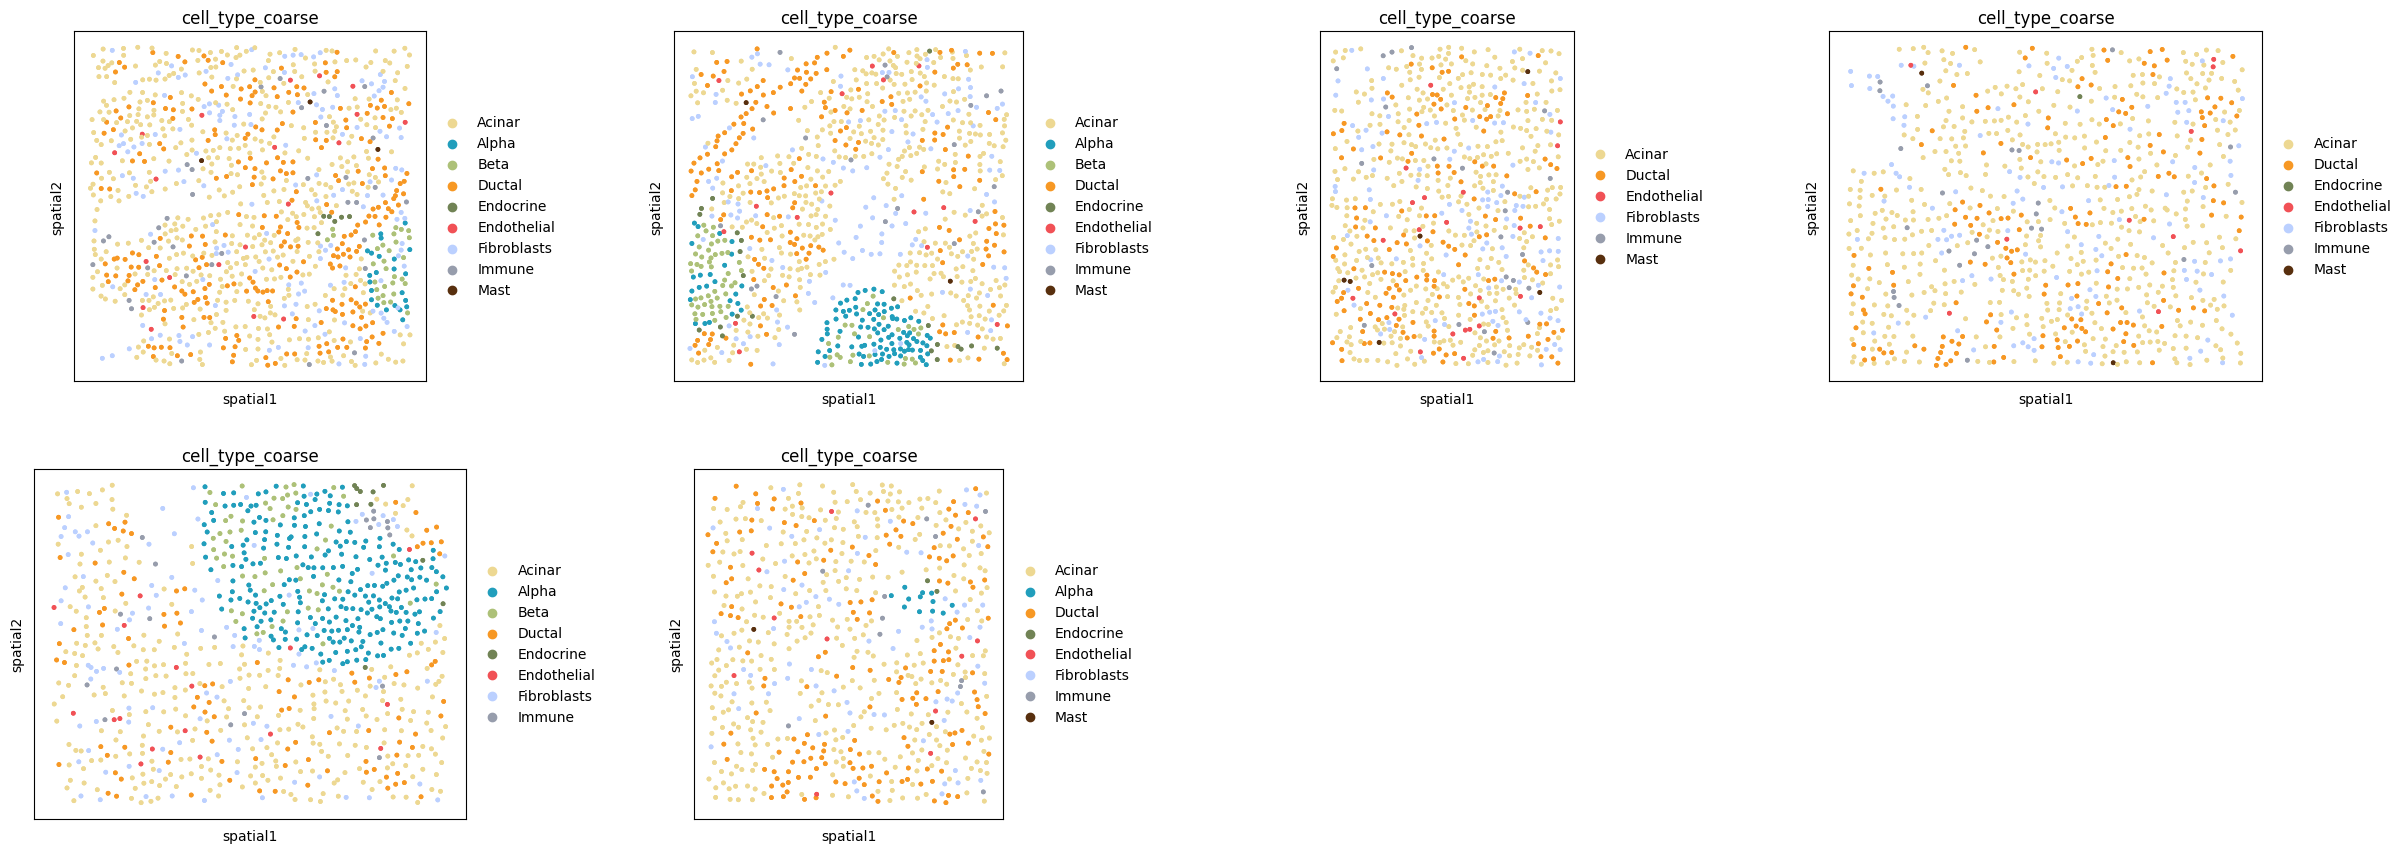

In [45]:
sq.pl.spatial_scatter(
                sub_adata,
                color = 'cell_type_coarse',
                spatial_key = 'spatial',
                shape=None,
                library_key='sliding_window', 
    )

### Interactions strength between cell types

First, we will use the attention matrices to calculate the interaction strength between cells of a class (e.i. cell type).

In [9]:
class_key = 'cell_type_coarse'
sliding_window_id = '12_1'

In [10]:
attention_matrix = attention_matrix_dict[sliding_window_id]
attention_matrix

NameError: name 'attention_matrix_dict' is not defined

In [ ]:
filtered_obs_csv = obs_csv[obs_csv['obs_names'].isin(attention_matrix.index)]
obs_name_to_cell_type = dict(zip(filtered_obs_csv['obs_names'], filtered_obs_csv[class_key]))
attention_matrix = attention_matrix.rename(index=obs_name_to_cell_type, columns=obs_name_to_cell_type)
attention_matrix

In [ ]:
# Compute the sum of attention values for each sender cell towards all receiver cells
attn_norm = compute_normalized_attention(attention_matrix, axis = 'both')

In [85]:
class_names = np.unique(sub_adata.obs['cell_type_coarse'][sub_adata.obs['fov'] == '12'])
K = len(class_names)
attn_map = pd.DataFrame(np.zeros((K, K)), index=class_names, columns=class_names)
attn_occurences = pd.DataFrame(np.zeros((K, K)), index=class_names, columns=class_names)
for sliding_window_id in np.unique(sub_adata.obs['sliding_window'][sub_adata.obs['fov'] == '12']):
    print(sliding_window_id)
    print(np.unique(sub_adata.obs['cell_type_coarse'][sub_adata.obs['sliding_window']==sliding_window_id]))
    # TODO: Incorrect mapping!
    attention_matrix = attention_matrix_dict[sliding_window_id]
    filtered_obs_csv = obs_csv[obs_csv['obs_names'].isin(attention_matrix.index)]
    obs_name_to_cell_type = dict(zip(filtered_obs_csv['obs_names'], filtered_obs_csv['cell_type_coarse']))
    attention_matrix = attention_matrix.rename(index=obs_name_to_cell_type, columns=obs_name_to_cell_type)
    attn_norm = normalized_class_attention(attention_matrix, axis = 'both')
    # Add values to attn_map and increment attn_occurences
    attn_map.loc[attn_norm.index, attn_norm.columns] += attn_norm
    attn_occurences.loc[attn_norm.index, attn_norm.columns] += 1

12_0
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']
12_1
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']
12_2
['Acinar' 'Ductal' 'Endothelial' 'Fibroblasts' 'Immune' 'Mast']
12_3
['Acinar' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts' 'Immune' 'Mast']
12_4
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune']
12_5
['Acinar' 'Alpha' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']


In [86]:
attn_norm = attn_map/attn_occurences

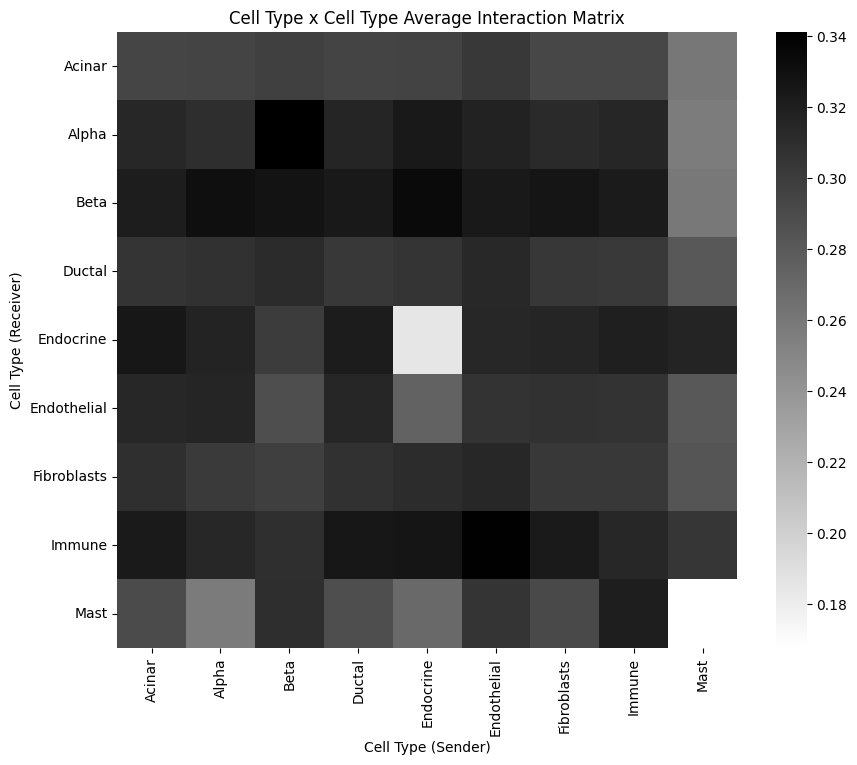

In [87]:
plt.figure(figsize=(10, 8))
sns.heatmap(attn_norm, cmap = 'gray_r')
plt.title('Cell Type x Cell Type Average Interaction Matrix')
plt.xlabel('Cell Type (Sender)')
plt.ylabel('Cell Type (Receiver)')
plt.savefig(f'/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/pancreas/heat_map_ND-T1D.png')
plt.show()

### Sender-receiver interaction 

In [16]:
def normalize_attention(attention_matrix, clamp = 0.05):
    np.fill_diagonal(attention_matrix.values, 0)
    
    # Clamp and scale attention matrix
    scores = torch.tensor(attention_matrix.values)
    if clamp:
        q05, q95 = torch.quantile(scores, clamp), torch.quantile(scores, 1-clamp)
        scores = np.clip(scores, a_min=q05, a_max=q95)
    scores = MinMaxScaler(feature_range=(0, 1)).fit_transform(scores)
    return scores

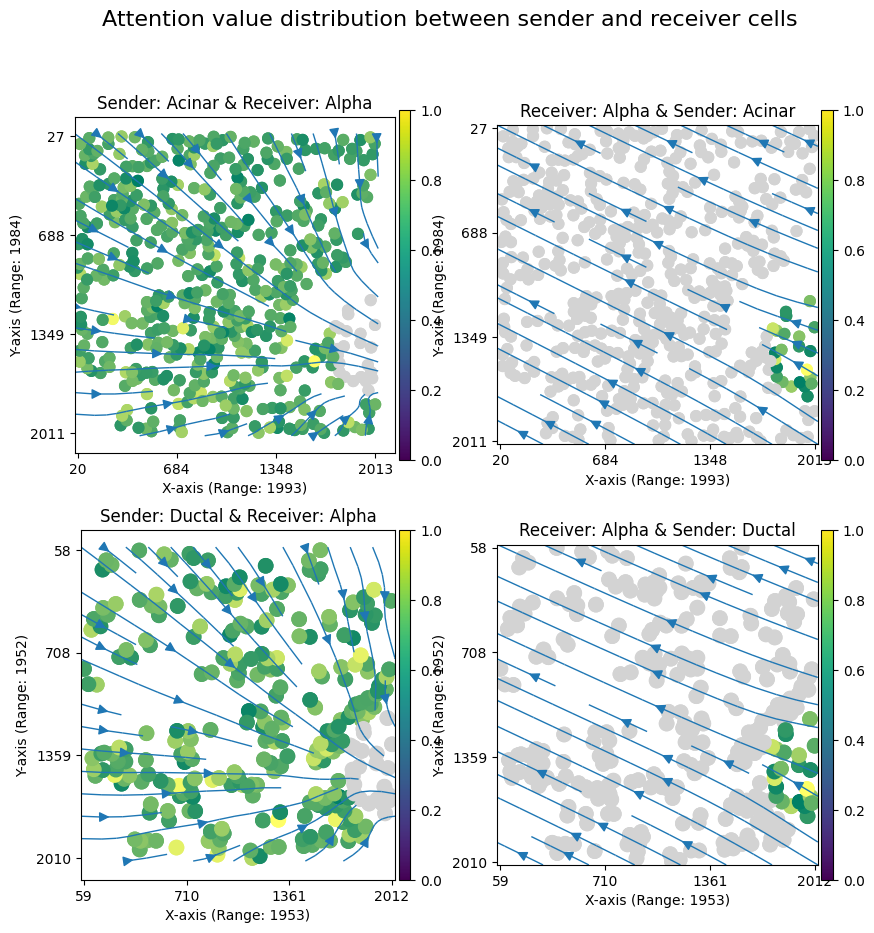

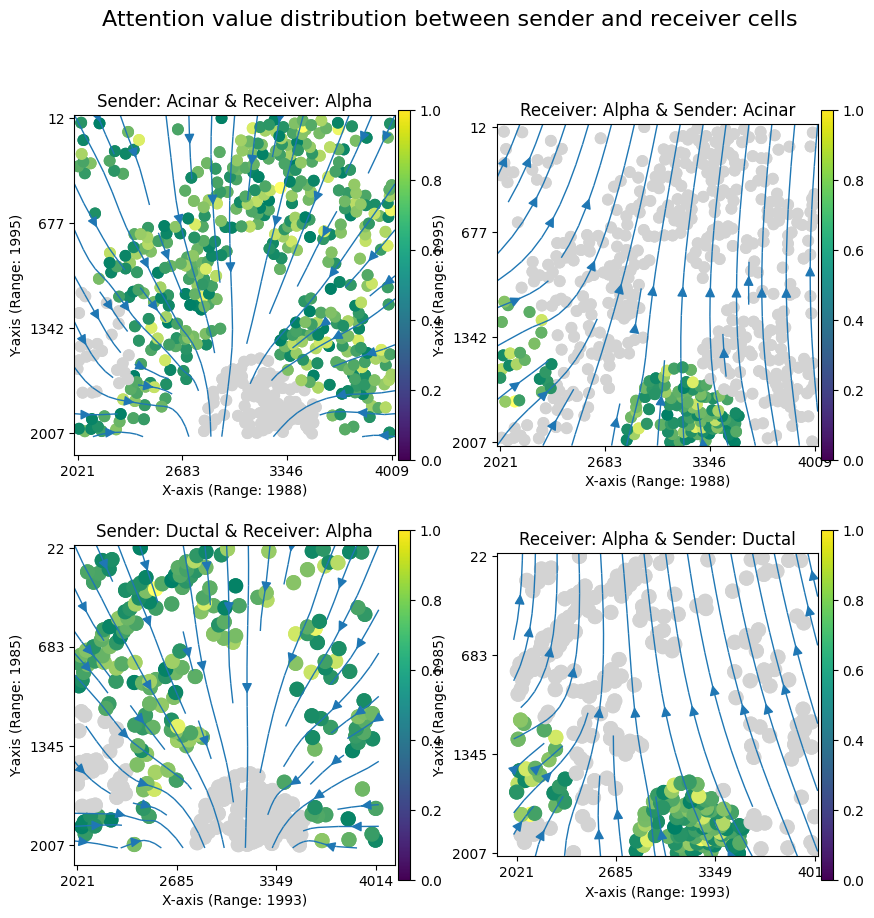

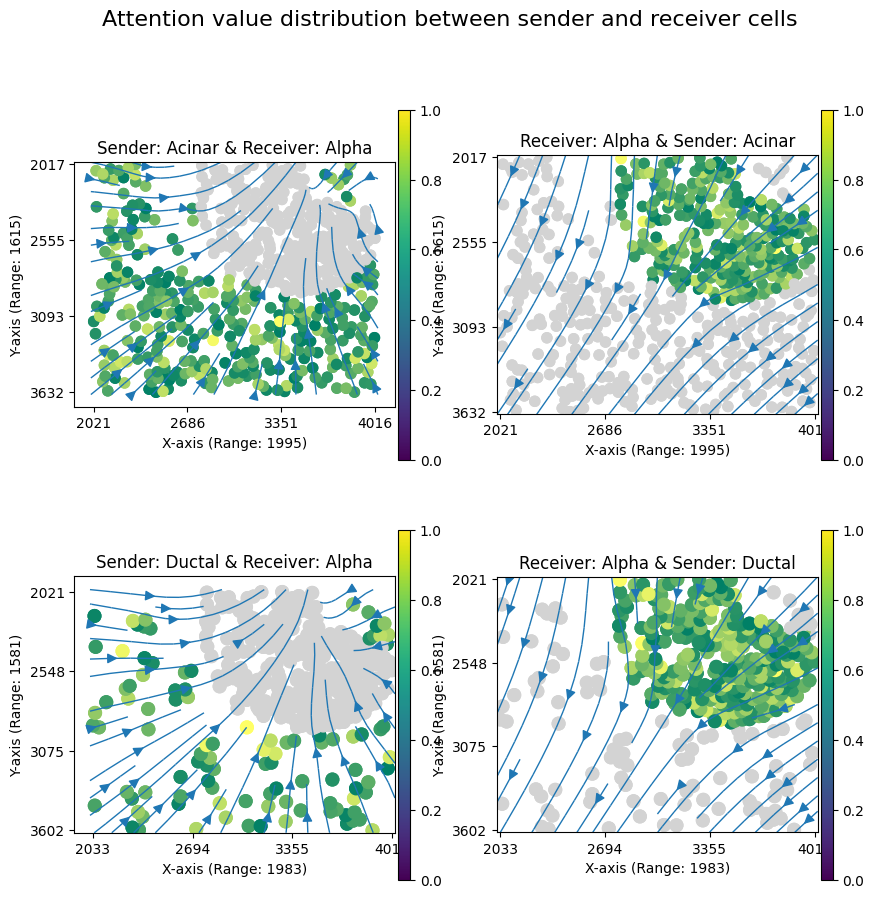

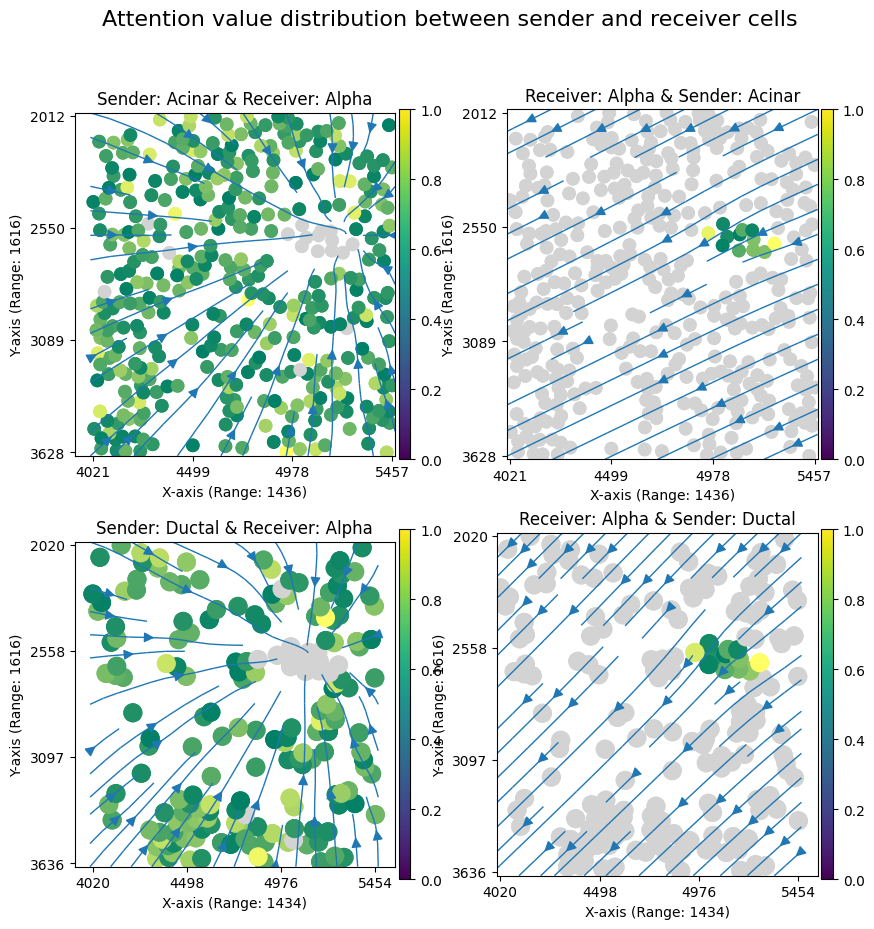

In [17]:
sender = ['Acinar', 'Ductal']
receiver = 'Alpha'
class_name = 'cell_type_coarse'

for sliding_window_id in attention_matrix_dict.keys():
    attention_matrix = attention_matrix_dict[sliding_window_id]
    val_sub_adata = sub_adata[sub_adata.obs['sliding_window'] == sliding_window_id]
    val_sub_adata = val_sub_adata[val_sub_adata.obs_names.isin(attention_matrix.index)]
    if receiver in np.unique(val_sub_adata.obs[class_name]):
        attn_norm = normalized_attention(attention_matrix)
        val_sub_adata.obsm['attention_matrix'] = attn_norm
        plot_attention_sender_receiver(val_sub_adata, sender, receiver, cell_type_key = 'cell_type_coarse', attn_matrix_key='attention_matrix', add_streamline = True, discrete_values=True, show_index = True)